# Steps:
For each tree
- Randomly select n sample
- Build a tree using Random split
- Compute path length for each data point

After building all trees:
- Compute average path length
- Normalize using C(n) | Average path of tree
- Compute anomaly score
- Classify using continuation threshold

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.ensemble import IsolationForest


In [3]:
!pip install ucimlrepo

In [8]:
from ucimlrepo import fetch_ucirepo

In [11]:
#load the dataset
air_quality = fetch_ucirepo(id=360)
#check the dataset


In [12]:
air_quality

{'data': {'ids': None,
  'features':            Date      Time  CO(GT)  PT08.S1(CO)  ...  PT08.S5(O3)     T    RH      AH
  0     3/10/2004  18:00:00     2.6         1360  ...         1268  13.6  48.9  0.7578
  1     3/10/2004  19:00:00     2.0         1292  ...          972  13.3  47.7  0.7255
  2     3/10/2004  20:00:00     2.2         1402  ...         1074  11.9  54.0  0.7502
  3     3/10/2004  21:00:00     2.2         1376  ...         1203  11.0  60.0  0.7867
  4     3/10/2004  22:00:00     1.6         1272  ...         1110  11.2  59.6  0.7888
  ...         ...       ...     ...          ...  ...          ...   ...   ...     ...
  9352   4/4/2005  10:00:00     3.1         1314  ...         1729  21.9  29.3  0.7568
  9353   4/4/2005  11:00:00     2.4         1163  ...         1269  24.3  23.7  0.7119
  9354   4/4/2005  12:00:00     2.4         1142  ...         1092  26.9  18.3  0.6406
  9355   4/4/2005  13:00:00     2.1         1003  ...          770  28.3  13.5  0.5139
  9356  

In [ ]:
#convert to dataframe
df  = air_quality.data.features

In [17]:
#select specific columns for anomaly detection
features = df[['CO(GT)','C6H6(GT)','NOx(GT)','NO2(GT)']]

In [18]:
features.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116


In [20]:
#cheking for missing values
features.isnull().sum()

CO(GT)      0
C6H6(GT)    0
NOx(GT)     0
NO2(GT)     0
dtype: int64

In [22]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CO(GT)    9357 non-null   float64
 1   C6H6(GT)  9357 non-null   float64
 2   NOx(GT)   9357 non-null   int64  
 3   NO2(GT)   9357 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 292.5 KB


In [23]:
# parameters for isolation forest
n_estimators = 100 #number of trees in the forest
contamination = 0.01 #proportion of outliers in the dataset (adjust based on your data)
sample_size = 256 #number of samples to draw from the dataset to train each base estimator

In [25]:
# train the isolation forest model
model = IsolationForest(n_estimators=n_estimators,contamination=contamination,max_samples= sample_size,random_state=42)
model.fit(features)

#predict anomalies
anomaly_labels=model.predict(features)
#-1 for anomalies and 1 for normal data points
anomaly_labels


array([1, 1, 1, ..., 1, 1, 1], shape=(9357,))

In [26]:
#create new column in the original dataframe to story anomaly labels
features['anomaly'] = anomaly_labels
features.head()

C:\Users\supev\AppData\Local\Temp\ipykernel_30380\3134922493.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['anomaly'] = anomaly_labels


,CO(GT),C6H6(GT),NOx(GT),NO2(GT),anomaly
0,2.6,11.9,166,113,1
1,2.0,9.4,103,92,1
2,2.2,9.0,131,114,1
3,2.2,9.2,172,122,1
4,1.6,6.5,131,116,1


In [29]:
#finding the number of anomalies detected using valuecount
features['anomaly'].value_counts()


anomaly
 1    9263
-1      94
Name: count, dtype: int64

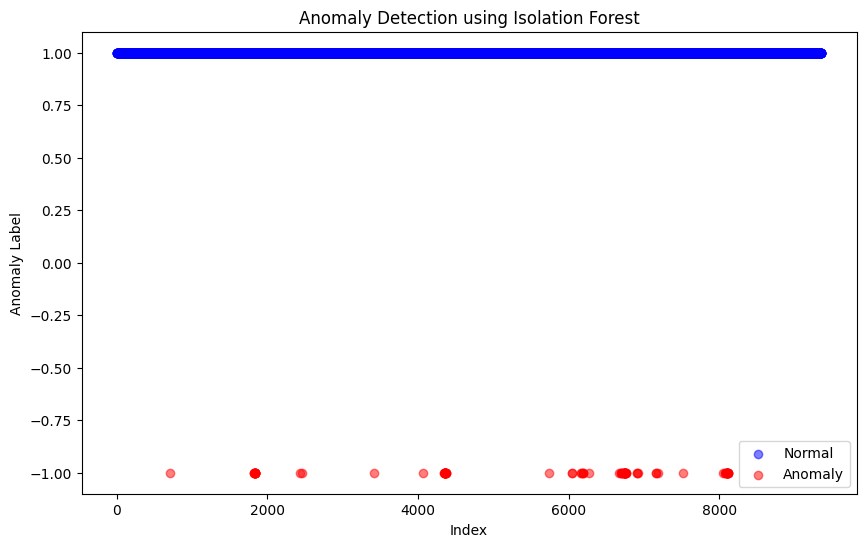

In [31]:
#visualize the anomalies
plt.figure(figsize=(10,6))

#plot normal instances
normal_data = features[features['anomaly']==1]
plt.scatter(normal_data.index,normal_data['anomaly'],color='blue',label='Normal',alpha=0.5)
#plot anomalies
anomalies = features[features['anomaly']==-1]
plt.scatter(anomalies.index,anomalies['anomaly'],color='red',label='Anomaly',alpha=0.5)
plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('Index')
plt.ylabel('Anomaly Label')
plt.legend()
plt.show()

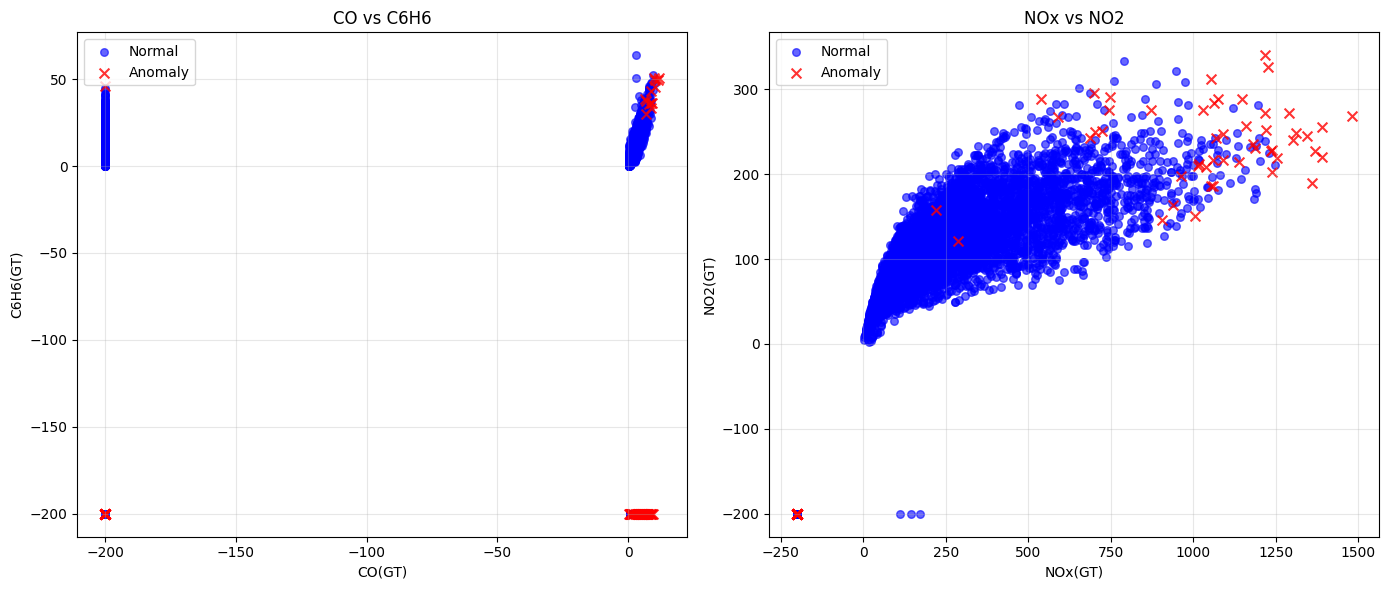

In [33]:
# Separate normal and anomaly data
fig,axes = plt.subplots(1,2,figsize=(14,6))
normal = features[features['anomaly'] == 1]
anomaly = features[features['anomaly'] == -1]

# Plot 1: CO vs C6H6
axes[0].scatter(
    normal['CO(GT)'],
    normal['C6H6(GT)'],
    color='blue',
    label='Normal',
    alpha=0.6,
    s=30
)

axes[0].scatter(
    anomaly['CO(GT)'],
    anomaly['C6H6(GT)'],
    color='red',
    label='Anomaly',
    alpha=0.8,
    s=50,
    marker='x'
)

axes[0].set_xlabel('CO(GT)')
axes[0].set_ylabel('C6H6(GT)')
axes[0].set_title('CO vs C6H6')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: NOx vs NO2
axes[1].scatter(
    normal['NOx(GT)'],
    normal['NO2(GT)'],
    color='blue',
    label='Normal',
    alpha=0.6,
    s=30
)

axes[1].scatter(
    anomaly['NOx(GT)'],
    anomaly['NO2(GT)'],
    color='red',
    label='Anomaly',
    alpha=0.8,
    s=50,
    marker='x'
)

axes[1].set_xlabel('NOx(GT)')
axes[1].set_ylabel('NO2(GT)')
axes[1].set_title('NOx vs NO2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [46]:
%pip install plotly
import plotly.graph_objects as go
import numpy as np
 
# Separate normal and anomaly
normal = features[features['anomaly'] == 1]
anomaly = features[features['anomaly'] == -1]
 
fig = go.Figure()
 
# Normal points
fig.add_trace(go.Scatter3d(
    x=normal['CO(GT)'],
    y=normal['C6H6(GT)'],
    z=normal['NOx(GT)'],
    mode='markers',
    name='Normal',
    marker=dict(
        size=6,
        color=normal['NO2(GT)'],   # 4th dimension as color
        colorscale='Blues',
        opacity=0.6,
        colorbar=dict(title='NO2(GT)')
    )
))
 
# Anomaly points
fig.add_trace(go.Scatter3d(
    x=anomaly['CO(GT)'],
    y=anomaly['C6H6(GT)'],
    z=anomaly['NOx(GT)'],
    mode='markers',
    name='Anomaly',
    marker=dict(
        size=8,
        color=anomaly['NO2(GT)'],
        colorscale='Reds',
        opacity=0.9,
        symbol='diamond'
    )
))
 
# Layout
fig.update_layout(
    title='4D Scatter Plot (Color = NO2(GT))',
    scene=dict(
        xaxis_title='CO(GT)',
        yaxis_title='C6H6(GT)',
        zaxis_title='NOx(GT)'
    ),
    width=900,
    height=700
)


 

Note: you may need to restart the kernel to use updated packages.


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': {'bdata': ('cQBcAHIAegB0AGAATQBMADwAOP8iAB' ... 'A1AF0AmwCuALsAvgCzAK8AnACoAA=='),
                                   'dtype': 'i2'},
                         'colorbar': {'title': {'text': 'NO2(GT)'}},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'opacity': 0.6,
                         'size': 6},
              'mode': 'markers',
              'name': 'Normal',
              'type': 'scatter3d',
              'x': {'bdata': ('zczMzMzMBEAAAAAAAAAAQJqZmZmZmQ' ... 'MzMwNAzczMzMzMAECamZmZmZkBQA=='),
                    'dtype': 'f8'},
              'y': {'bdata': ('zczMzMzMJ0DNzMzMzMwiQAAAAAAAAC' ... 'zMzChAAAAAAAAAI0DNzMzMzMwnQA=='),
                    'dtype': 'f8'},
              'z': {'bdata': ('pgBnAIMArACDAFkAPgA+AC0AOP8VAB' ... 'BNALYAUgJKAgsC2AFhASUB6wAJAQ=='),
                    'dtype': 'i2'}},
             {'marker': {'color': {'bdata': ('OP84/zj/OP84/zj/OP84/zj/OP84/z' ... 'gBIwEUAfoA+wATATgBVAFGARwBIQE='),
                                   'dtype': 'i2'},
                         'colorscale': [[0.0, 'rgb(255,245,240)'], [0.125,
                                        'rgb(254,224,210)'], [0.25,
                                        'rgb(252,187,161)'], [0.375,
                                        'rgb(252,146,114)'], [0.5,
                                        'rgb(251,106,74)'], [0.625,
                                        'rgb(239,59,44)'], [0.75,
                                        'rgb(203,24,29)'], [0.875,
                                        'rgb(165,15,21)'], [1.0, 'rgb(103,0,13)']],
                         'opacity': 0.9,
                         'size': 8,
                         'symbol': 'diamond'},
              'mode': 'markers',
              'name': 'Anomaly',
              'type': 'scatter3d',
              'x': {'bdata': ('AAAAAAAA8D8AAAAAAABpwAAAAAAAAG' ... 'ZmZmYaQAAAAAAAABpAZmZmZmZmHEA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AAAAAAAAacAAAAAAAABpwAAAAAAAAG' ... 'AAAABpwAAAAAAAAGnAAAAAAAAAacA='),
                    'dtype': 'f8'},
              'z': {'bdata': ('OP84/zj/OP84/zj/OP84/zj/OP84/z' ... 'wC6wLqAr4C0wJoAx4EwgTLBCUEMwQ='),
                    'dtype': 'i2'}}],
    'layout': {'height': 700,
               'scene': {'xaxis': {'title': {'text': 'CO(GT)'}},
                         'yaxis': {'title': {'text': 'C6H6(GT)'}},
                         'zaxis': {'title': {'text': 'NOx(GT)'}}},
               'template': '...',
               'title': {'text': '4D Scatter Plot (Color = NO2(GT))'},
               'width': 900}
})